In [1]:
import os
import multiprocessing

num_cores = multiprocessing.cpu_count()
print(f"La máquina tiene {num_cores} núcleos disponibles.")
hilos_optimos = str(min(num_cores, 64))
print(f"Configurando OpenBLAS para usar {hilos_optimos} hilos máximos...")
os.environ['OPENBLAS_NUM_THREADS'] = hilos_optimos
os.environ['MKL_NUM_THREADS'] = hilos_optimos
os.environ['OMP_NUM_THREADS'] = hilos_optimos

La máquina tiene 224 núcleos disponibles.
Configurando OpenBLAS para usar 64 hilos máximos...


In [2]:
import numpy as np
import pandas as pd
import itertools
import json
from pathlib import Path
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, accuracy_score, recall_score,classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
import gc

In [3]:
X = pd.read_pickle("Sets_Xy/X.pkl")
y = pd.read_pickle("Sets_Xy/y.pkl")

from sklearn.model_selection import train_test_split

#Division estratificada para muestras de cada clase a nivel de cada subset

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, 
    random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, 
    random_state=42)

#Encoding de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

mapeo_labels = pd.DataFrame({
    "label_original": le.classes_,
    "label_encoded": range(len(le.classes_))
})
print("Mapeo de etiquetas:\n", mapeo_labels)
class_names = le.classes_

Mapeo de etiquetas:
                label_original  label_encoded
0                      BENIGN              0
1                         Bot              1
2                        DDoS              2
3               DoS GoldenEye              3
4                    DoS Hulk              4
5            DoS Slowhttptest              5
6               DoS slowloris              6
7                 FTP-Patator              7
8                  Heartbleed              8
9                Infiltration              9
10                   PortScan             10
11                SSH-Patator             11
12    Web Attack  Brute Force             12
13  Web Attack  Sql Injection             13
14            Web Attack  XSS             14


In [4]:
import joblib

X_train_none = joblib.load("Sets_Oversampling_2/X_train_none.joblib")
y_train_none = joblib.load("Sets_Oversampling_2/y_train_none.joblib")

X_val = pd.read_pickle("Sets_Post_Scaled_Imp/X_val_scaled_bayesian.pkl")
y_val = pd.DataFrame(y_val)

X_test = pd.read_pickle("Sets_Post_Scaled_Imp/X_test_scaled_bayesian.pkl")
y_test = pd.DataFrame(y_test)

y_val_1d = y_val.values.ravel() if isinstance(y_val, pd.DataFrame) else y_val.ravel()
y_test_1d = y_test.values.ravel() if isinstance(y_test, pd.DataFrame) else y_test.ravel()


Analisis de Distribucion: ORIGINAL (NONE)
Total de muestras: 1,823,353
Número de clases: 15
Imbalance Ratio: 179125.12:1

 Clase  Conteo Porcentaje (%)
     0 1433001       78.5915%
     4  161751        8.8711%
    10  111251        6.1015%
     2   89619        4.9151%
     3    7205        0.3952%
     7    5557        0.3048%
    11    4128        0.2264%
     6    4057        0.2225%
     5    3849        0.2111%
     1    1376        0.0755%
    12    1055        0.0579%
    14     456        0.0250%
     9      25        0.0014%
    13      15        0.0008%
     8       8        0.0004%


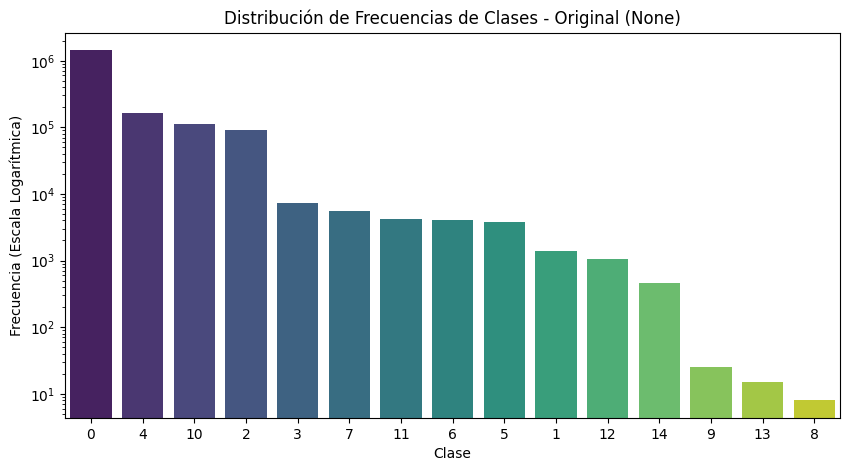

In [5]:
def analizar_distribuciones(y, nombre_dataset=""):
    total_muestras = len(y)
    classes, counts = np.unique(y, return_counts=True)
    
    sorted_idx = np.argsort(counts)[::-1]
    classes = classes[sorted_idx]
    counts = counts[sorted_idx]
    
    majority_count = counts[0]
    minority_count = counts[-1]
    imbalance_ratio = majority_count / minority_count
    
    print(f"Analisis de Distribucion: {nombre_dataset.upper()}")
    print(f"Total de muestras: {total_muestras:,}")
    print(f"Número de clases: {len(classes)}")
    print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1\n")
    
    porcentajes = (counts / total_muestras) * 100
    df_dist = pd.DataFrame({
        'Clase': classes,
        'Conteo': counts,
        'Porcentaje (%)': porcentajes
    })
    
    df_dist['Porcentaje (%)'] = df_dist['Porcentaje (%)'].map('{:.4f}%'.format)
    
    print(df_dist.to_string(index=False))
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=[str(c) for c in classes], y=counts, palette="viridis", hue=[str(c) for c in classes], legend=False)
    plt.title(f"Distribución de Frecuencias de Clases - {nombre_dataset}")
    plt.xlabel("Clase")
    plt.ylabel("Frecuencia (Escala Logarítmica)")
    plt.yscale('log')
    plt.show()
    
    return classes, counts

classes, counts = analizar_distribuciones(y_train_none, "Original (None)")

In [6]:
import joblib
import numpy as np
from collections import Counter
import pandas as pd

archivos_y_train = [
    "y_train_E1_Benigno_Y_Ataques_Camuflados.joblib",
    "y_train_E2_Mayoritarios.joblib",
    "y_train_E3_DoS.joblib",
    "y_train_E4_Patator.joblib",
    "y_train_E5_Minoritarios.joblib"
]

carpeta_sets = "Sets_Expertos_MoE_2"

for archivo in archivos_y_train:
    ruta_completa = f"{carpeta_sets}/{archivo}"
    
    try:
        y_data = joblib.load(ruta_completa)
        
        if isinstance(y_data, pd.DataFrame) or isinstance(y_data, pd.Series):
            y_data = y_data.values.ravel()
            
        conteo = Counter(y_data)
        
        clases_ordenadas = conteo.most_common()
        
        print(f"Análisis de: {archivo}")
        print("Clases y sus conteos:")
        
        for clase, cantidad in clases_ordenadas:
            print(f"  Clase {int(clase)}: {cantidad:,} muestras")
        print("\n")
        
    except FileNotFoundError:
        print(f"No se encontró el archivo: {ruta_completa}. Revisa la ruta.\n")

Análisis de: y_train_E1_Benigno_Y_Ataques_Camuflados.joblib
Clases y sus conteos:
  Clase 0: 1,433,001 muestras
  Clase 4: 12,526 muestras
  Clase 10: 8,612 muestras
  Clase 2: 6,937 muestras
  Clase 1: 1,376 muestras
  Clase 12: 1,055 muestras
  Clase 3: 558 muestras
  Clase 14: 456 muestras
  Clase 7: 431 muestras
  Clase 11: 320 muestras
  Clase 6: 315 muestras
  Clase 5: 298 muestras
  Clase 13: 15 muestras
  Clase 9: 2 muestras
  Clase 8: 1 muestras


Análisis de: y_train_E2_Mayoritarios.joblib
Clases y sus conteos:
  Clase 0: 588,603 muestras
  Clase 4: 161,751 muestras
  Clase 10: 111,251 muestras
  Clase 2: 89,619 muestras
  Clase 3: 2,960 muestras
  Clase 7: 2,283 muestras
  Clase 11: 1,696 muestras
  Clase 6: 1,667 muestras
  Clase 5: 1,581 muestras
  Clase 1: 566 muestras
  Clase 12: 434 muestras
  Clase 14: 188 muestras
  Clase 9: 11 muestras
  Clase 13: 7 muestras
  Clase 8: 4 muestras


Análisis de: y_train_E3_DoS.joblib
Clases y sus conteos:
  Clase 0: 61,003 muestras
  

In [7]:
X_train_base = joblib.load("Sets_Oversampling_2/X_train_none.joblib")
y_train_base = joblib.load("Sets_Oversampling_2/y_train_none.joblib")

if isinstance(y_train_base, pd.DataFrame) or isinstance(y_train_base, pd.Series):
    y_train_base = y_train_base.values.ravel()

CLASE_BENIGNA = 0
clases_experto_1 = [0, 1, 12, 13, 14]
clases_experto_2 = [2, 4, 10]
clases_experto_3 = [3, 5, 6]
clases_experto_4 = [7, 11]
clases_experto_5 = [8, 9]

In [8]:
import numpy as np
import pandas as pd
import joblib
import os
from collections import Counter

os.makedirs("Sets_Expertos_MoE_2", exist_ok=True)

def predecir_tamano_post_smote(y_objetivo, target_large=200000):
    counts = Counter(y_objetivo)
    total_futuro = 0
    
    for cls, cnt in counts.items():
        if cls == CLASE_BENIGNA:
            total_futuro += cnt
        elif cnt < 1000: 
            total_futuro += max(cnt * 50, 30000)     
        elif cnt < 5000:
            total_futuro += max(cnt * 20, 60000)
        elif cnt < 10000:
            total_futuro += max(cnt * 15, 100000)
        else:
            total_futuro += max(cnt, target_large)
            
    return total_futuro

def estratificar_con_minimo(X_pool, y_pool, n_samples):
    counts = Counter(y_pool)
    total_pool = len(y_pool)
    unique_classes = list(counts.keys())

    if n_samples >= total_pool:
        return X_pool, y_pool

    target_counts = {cls: 1 for cls in unique_classes}
    restantes = n_samples - len(unique_classes)

    for cls in unique_classes:
        prop = counts[cls] / total_pool
        adicionales = int(np.floor(restantes * prop))
        target_counts[cls] += adicionales
        target_counts[cls] = min(target_counts[cls], counts[cls])

    actual_total = sum(target_counts.values())
    faltantes = n_samples - actual_total

    if faltantes > 0:
        clases_ordenadas = sorted(unique_classes, key=lambda c: counts[c], reverse=True)
        for cls in clases_ordenadas:
            if faltantes == 0:
                break
            espacio_disponible = counts[cls] - target_counts[cls]
            if espacio_disponible > 0:
                agregar = min(faltantes, espacio_disponible)
                target_counts[cls] += agregar
                faltantes -= agregar

    indices_muestreados = []
    rng = np.random.default_rng(42)
    
    for cls, t_count in target_counts.items():
        idx_clase = np.where(y_pool == cls)[0]
        seleccion = rng.choice(idx_clase, size=t_count, replace=False)
        indices_muestreados.extend(seleccion)

    rng.shuffle(indices_muestreados)

    if hasattr(X_pool, 'iloc'):
        X_sample = X_pool.iloc[indices_muestreados]
    else:
        X_sample = X_pool[indices_muestreados]

    y_sample = y_pool[indices_muestreados]

    return X_sample, y_sample

def generar_subset_experto_exacto(X, y, clases_objetivo, clase_benigna=0, nombre_experto="Experto"):
    mask_objetivo = np.isin(y, clases_objetivo)
    X_objetivo = X[mask_objetivo]
    y_objetivo = y[mask_objetivo]
    
    mask_ruido = ~np.isin(y, clases_objetivo)
    X_ruido_pool = X[mask_ruido]
    y_ruido_pool = y[mask_ruido]
    
    tamano_objetivo_futuro = predecir_tamano_post_smote(y_objetivo)
    
    n_ruido = tamano_objetivo_futuro
    n_ruido = min(n_ruido, len(y_ruido_pool))
    
    if n_ruido > 0:
        if n_ruido == len(y_ruido_pool):
            X_ruido_sample = X_ruido_pool
            y_ruido_sample = y_ruido_pool
        else:
            X_ruido_sample, y_ruido_sample = estratificar_con_minimo(X_ruido_pool, y_ruido_pool, n_samples=n_ruido)
        
        if hasattr(X, 'iloc'):
            X_final = pd.concat([X_objetivo, X_ruido_sample], axis=0)
        else:
            X_final = np.vstack((X_objetivo, X_ruido_sample))
        y_final = np.concatenate([y_objetivo, y_ruido_sample])
    else:
        X_final = X_objetivo
        y_final = y_objetivo

    # joblib.dump(X_final, f"Sets_Expertos_MoE/X_train_{nombre_experto}.joblib")
    # joblib.dump(y_final, f"Sets_Expertos_MoE/y_train_{nombre_experto}.joblib")
    
    print(f"{nombre_experto.upper()}")
    muestras_objetivo_actual = len(y_objetivo)
    muestras_ruido_actual = len(y_final) - muestras_objetivo_actual
    
    print(f"Estado Antes de SMOTE:")
    print(f"Objetivo: {muestras_objetivo_actual:,} | Ruido inyectado: {muestras_ruido_actual:,}")
    
    total_futuro = tamano_objetivo_futuro + n_ruido
    pct_obj = (tamano_objetivo_futuro / total_futuro) * 100
    pct_ruido = (n_ruido / total_futuro) * 100
    
    print(f"Estado Post-SMOTE Estimado:")
    print(f"Objetivo: {tamano_objetivo_futuro:,} ({pct_obj:.2f}%) | Ruido: {n_ruido:,} ({pct_ruido:.2f}%)\n")
    
    return X_final, y_final

print("Evaluando subsets de expertos con las nuevas reglas de balanceo...\n")

X_e1, y_e1 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_1, nombre_experto="E1_Benigno_Y_Ataques_Camuflados")
X_e2, y_e2 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_2, nombre_experto="E2_Mayoritarios")
X_e3, y_e3 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_3, nombre_experto="E3_DoS")
X_e4, y_e4 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_4, nombre_experto="E4_Patator")
X_e5, y_e5 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_5, nombre_experto="E5_Minoritarios")

Evaluando subsets de expertos con las nuevas reglas de balanceo...



E1_BENIGNO_Y_ATAQUES_CAMUFLADOS
Estado Antes de SMOTE:
Objetivo: 1,435,903 | Ruido inyectado: 387,450
Estado Post-SMOTE Estimado:
Objetivo: 1,613,001 (80.63%) | Ruido: 387,450 (19.37%)

E2_MAYORITARIOS
Estado Antes de SMOTE:
Objetivo: 362,621 | Ruido inyectado: 600,000
Estado Post-SMOTE Estimado:
Objetivo: 600,000 (50.00%) | Ruido: 600,000 (50.00%)

E3_DOS
Estado Antes de SMOTE:
Objetivo: 15,111 | Ruido inyectado: 266,195
Estado Post-SMOTE Estimado:
Objetivo: 266,195 (50.00%) | Ruido: 266,195 (50.00%)

E4_PATATOR
Estado Antes de SMOTE:
Objetivo: 9,685 | Ruido inyectado: 182,560
Estado Post-SMOTE Estimado:
Objetivo: 182,560 (50.00%) | Ruido: 182,560 (50.00%)

E5_MINORITARIOS
Estado Antes de SMOTE:
Objetivo: 33 | Ruido inyectado: 60,000
Estado Post-SMOTE Estimado:
Objetivo: 60,000 (50.00%) | Ruido: 60,000 (50.00%)



In [9]:
def get_ids_proportions(y, clases_experto, target_large=200000):
    counts = Counter(y)
    proportion_dict = {}

    for cls in clases_experto:
        cnt = counts.get(cls, 0)
        if cnt == 0: continue
            
        if cls == 0: 
            continue
        elif cnt < 1000:
            proportion_dict[cls] = max(cnt * 50, 30000)
        elif cnt < 5000:
            proportion_dict[cls] = max(cnt * 20, 60000)
        elif cnt < 10000:
            proportion_dict[cls] = max(cnt * 15, 100000)
        else:
            proportion_dict[cls] = max(cnt, target_large)

    return proportion_dict

In [10]:
import joblib

proportion_dict_E1 = get_ids_proportions(y_train_base, clases_experto_1)
proportion_dict_E2 = get_ids_proportions(y_train_base, clases_experto_2)
proportion_dict_E3 = get_ids_proportions(y_train_base, clases_experto_3)
proportion_dict_E4 = get_ids_proportions(y_train_base, clases_experto_4)
proportion_dict_E5 = get_ids_proportions(y_train_base, clases_experto_5)

print("Diccionarios por sets para los expertos")
print(f"E1: {proportion_dict_E1}")
print(f"E2: {proportion_dict_E2}")
print(f"E3: {proportion_dict_E3}")
print(f"E4: {proportion_dict_E4}")
print(f"E5: {proportion_dict_E5}")

Diccionarios por sets para los expertos
E1: {1: 60000, 12: 60000, 13: 30000, 14: 30000}
E2: {2: 200000, 4: 200000, 10: 200000}
E3: {3: 108075, 5: 76980, 6: 81140}
E4: {7: 100000, 11: 82560}
E5: {8: 30000, 9: 30000}


In [11]:
class OversamplingWithArtifactAnalysis(BaseEstimator, TransformerMixin):

    def __init__(self, method='smote', proportion=None, random_state=42, n_neighbors=5, **kwargs):
        self.method = method
        self.proportion = proportion
        self.random_state = random_state
        self.n_neighbors = n_neighbors
        self.kwargs = kwargs
        
        self.oversampler_ = None
        self.artifacts_report_ = {}

    def fit(self, X, y=None):
        if self.method == 'none':
            return self

        if self.method == 'smote':
            self.oversampler_ = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
        elif self.method == 'smote_tomek':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTETomek(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        elif self.method == 'smote_enn':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTEENN(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        
        return self

    def fit_resample(self, X, y):
        feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
        orig_counts = Counter(y)

        if self.method == 'none':
            self._generar_reporte_avanzado(X, y, X, y, orig_counts, orig_counts)
            return X, y

        self.fit(X, y)
        
        X_res, y_res = self.oversampler_.fit_resample(X, y)
        new_counts = Counter(y_res)
        
        self._generar_reporte_avanzado(X, y, X_res, y_res, orig_counts, new_counts)

        if feature_names:
            X_res = pd.DataFrame(X_res, columns=feature_names)
            
        return X_res, y_res

    def _generar_reporte_avanzado(self, X_orig, y_orig, X_res, y_res, orig_counts, new_counts):
        if hasattr(X_orig, 'values'): X_orig = X_orig.values
        if hasattr(y_orig, 'values'): y_orig = y_orig.values
        if hasattr(X_res, 'values'): X_res = X_res.values
        if hasattr(y_res, 'values'): y_res = y_res.values

        reporte = {
            'metodo': self.method,
            'proporcion_config': {str(k): int(v) for k, v in self.proportion.items()} if isinstance(self.proportion, dict) else self.proportion,
            'resumen': {
                'muestras_antes': int(sum(orig_counts.values())),
                'muestras_despues': int(sum(new_counts.values())),
                'incremento_total': int(sum(new_counts.values()) - sum(orig_counts.values()))
            },
            'distribucion_original': {str(k): int(v) for k, v in orig_counts.items()},
            'distribucion_final': {str(k): int(v) for k, v in new_counts.items()},
            'analisis_por_clase': {}
        }

        unique_classes = np.unique(y_orig)
        print(f"\nCalculando métricas de artefactos para: {self.method.upper()}...")

        n_orig_total = len(X_orig)
        if self.method == 'smote':
            X_synth_global = X_res[n_orig_total:]
            y_synth_global = y_res[n_orig_total:]

        for clase in unique_classes:
            clase_str = str(clase)
            c_orig = orig_counts.get(clase, 0)
            c_new = new_counts.get(clase, 0)

            X_orig_c = X_orig[y_orig == clase]
            
            if self.method == 'smote':
                X_synth_c = X_synth_global[y_synth_global == clase]
            else:
                X_res_c = X_res[y_res == clase]
                if len(X_orig_c) > 0 and len(X_res_c) > 0:
                    nn_filter = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1).fit(X_orig_c)
                    dists, _ = nn_filter.kneighbors(X_res_c)
                    X_synth_c = X_res_c[dists.flatten() > 1e-6]
                else:
                    X_synth_c = np.array([])

            if c_new > c_orig: estado = "Oversampled"
            elif c_new < c_orig: estado = "Undersampled / Limpiado"
            else: estado = "Intacto"

            clase_info = {
                "estado": estado,
                "originales": int(c_orig),
                "finales": int(c_new),
                "sinteticas_puras_detectadas": int(len(X_synth_c)),
                "multiplicador": float(round(c_new / c_orig, 2)) if c_orig > 0 else 0.0
            }

            if len(X_orig_c) > 1 and len(X_synth_c) > 0 and estado != "Intacto":
                
                #Distancia interna original
                nn_baseline = NearestNeighbors(n_neighbors=2, metric='euclidean', n_jobs=-1)
                nn_baseline.fit(X_orig_c)
                dist_base, _ = nn_baseline.kneighbors(X_orig_c)
                mean_dist_base = float(np.mean(dist_base[:, 1]))

                #Distancia total de los datos nuevos hacia los originales
                nn_post = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
                nn_post.fit(X_orig_c)
                dist_post, _ = nn_post.kneighbors(X_synth_c)
                mean_dist_post = float(np.mean(dist_post))
                
                #Detectar duplicados exactos
                duplicados_pct = float(np.sum(dist_post < 1e-8) / len(dist_post) * 100)

                #Evaluación de Riesgo de Artefactos
                riesgo = "Bajo (Consistente)"
                if duplicados_pct > 5.0:
                    riesgo = f"Alto (Alerta de Duplicidad: {round(duplicados_pct, 1)}%)"
                elif mean_dist_base > 0 and (mean_dist_post > mean_dist_base * 2.5):
                    riesgo = "Alto (Artefactos Lejanos / Ruido)"

                clase_info["metricas_vecindario"] = {
                    "distancia_media_interna_original": float(round(mean_dist_base, 6)),
                    "distancia_media_sinteticos_a_originales": float(round(mean_dist_post, 6)),
                    "porcentaje_duplicados_exactos": float(round(duplicados_pct, 2)),
                    "riesgo_artefactos": riesgo
                }

            reporte['analisis_por_clase'][clase_str] = clase_info

        self.artifacts_report_ = reporte
        
        print(f"Análisis completado. Muestras: {reporte['resumen']['muestras_antes']} -> {reporte['resumen']['muestras_despues']}")
        
        for k, v in reporte['analisis_por_clase'].items():
            if 'metricas_vecindario' in v and "Alto" in v['metricas_vecindario']['riesgo_artefactos']:
                print(f"Precaución Clase {k}: {v['metricas_vecindario']['riesgo_artefactos']}")

    def transform(self, X):
        return X

    def get_artifacts_report(self):
        return self.artifacts_report_

    def save_report(self, filepath):
        with open(filepath, 'w') as f:
            json.dump(self.artifacts_report_, f, indent=2, default=str)

Analisis de Distribucion: SET-E1-PREVIO SMOTE
Total de muestras: 1,465,903
Número de clases: 15
Imbalance Ratio: 1433001.00:1

 Clase  Conteo Porcentaje (%)
   0.0 1433001       97.7555%
   4.0   12526        0.8545%
  10.0    8612        0.5875%
   2.0    6937        0.4732%
   1.0    1376        0.0939%
  12.0    1055        0.0720%
   3.0     558        0.0381%
  14.0     456        0.0311%
   7.0     431        0.0294%
  11.0     320        0.0218%
   6.0     315        0.0215%
   5.0     298        0.0203%
  13.0      15        0.0010%
   9.0       2        0.0001%
   8.0       1        0.0001%


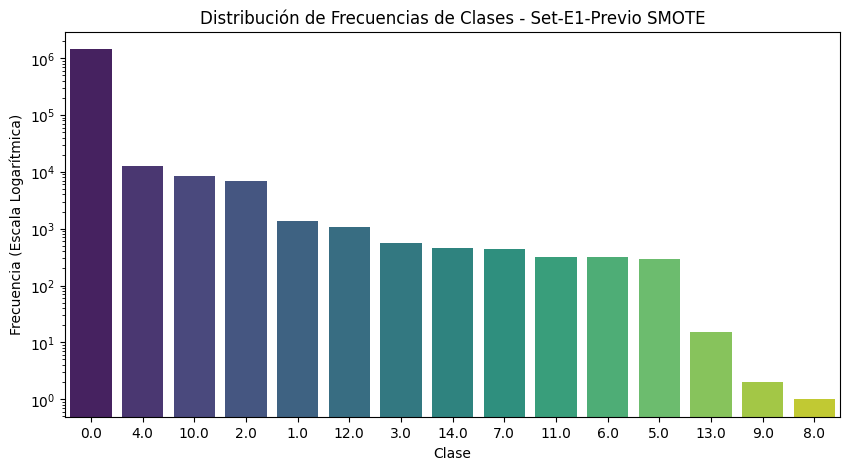

Analisis de Distribucion: SET-E2-PREVIO SMOTE
Total de muestras: 962,621
Número de clases: 15
Imbalance Ratio: 147150.75:1

 Clase  Conteo Porcentaje (%)
   0.0  588603       61.1459%
   4.0  161751       16.8032%
  10.0  111251       11.5571%
   2.0   89619        9.3099%
   3.0    2960        0.3075%
   7.0    2283        0.2372%
  11.0    1696        0.1762%
   6.0    1667        0.1732%
   5.0    1581        0.1642%
   1.0     566        0.0588%
  12.0     434        0.0451%
  14.0     188        0.0195%
   9.0      11        0.0011%
  13.0       7        0.0007%
   8.0       4        0.0004%


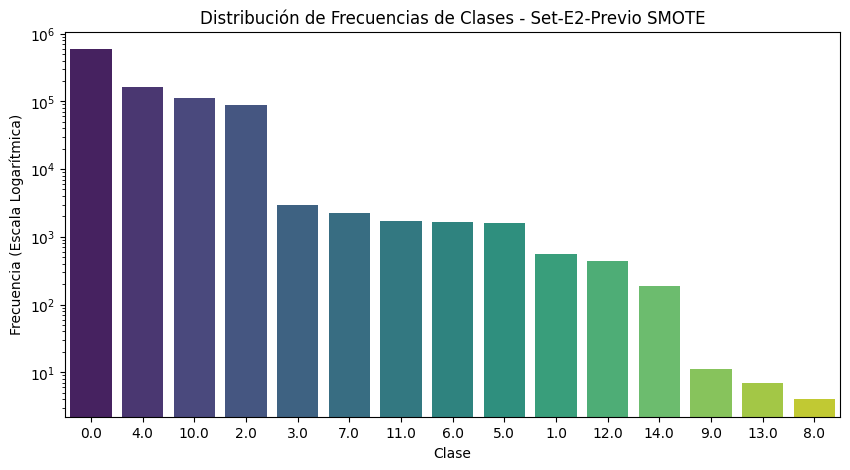

Analisis de Distribucion: SET-E3-PREVIO SMOTE
Total de muestras: 92,091
Número de clases: 15
Imbalance Ratio: 61003.00:1

 Clase  Conteo Porcentaje (%)
   0.0   61003       66.2421%
   3.0    7205        7.8238%
   4.0    6885        7.4763%
  10.0    4736        5.1427%
   6.0    4057        4.4054%
   5.0    3849        4.1796%
   2.0    3815        4.1426%
   7.0     237        0.2574%
  11.0     176        0.1911%
   1.0      59        0.0641%
  12.0      45        0.0489%
  14.0      20        0.0217%
   9.0       2        0.0022%
   8.0       1        0.0011%
  13.0       1        0.0011%


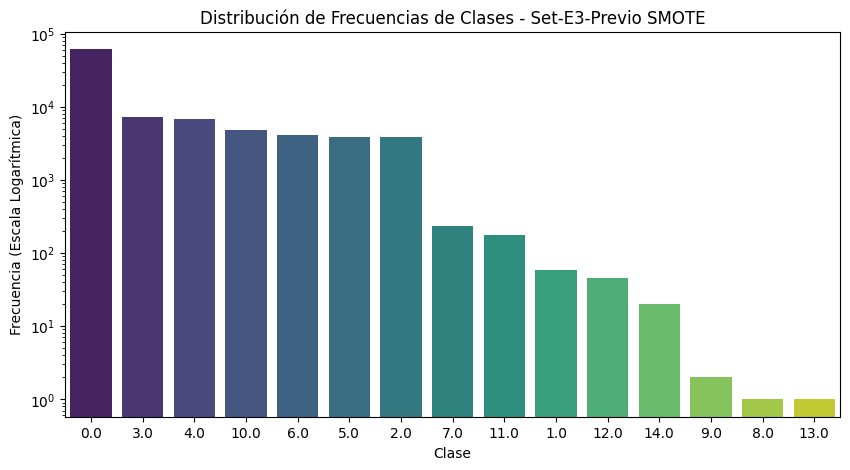

Analisis de Distribucion: SET-E4-PREVIO SMOTE
Total de muestras: 192,245
Número de clases: 15
Imbalance Ratio: 144239.00:1

 Clase  Conteo Porcentaje (%)
   0.0  144239       75.0287%
   4.0   16281        8.4689%
  10.0   11198        5.8249%
   2.0    9021        4.6924%
   7.0    5557        2.8906%
  11.0    4128        2.1473%
   3.0     726        0.3776%
   6.0     409        0.2127%
   5.0     388        0.2018%
   1.0     139        0.0723%
  12.0     107        0.0557%
  14.0      46        0.0239%
   9.0       3        0.0016%
  13.0       2        0.0010%
   8.0       1        0.0005%


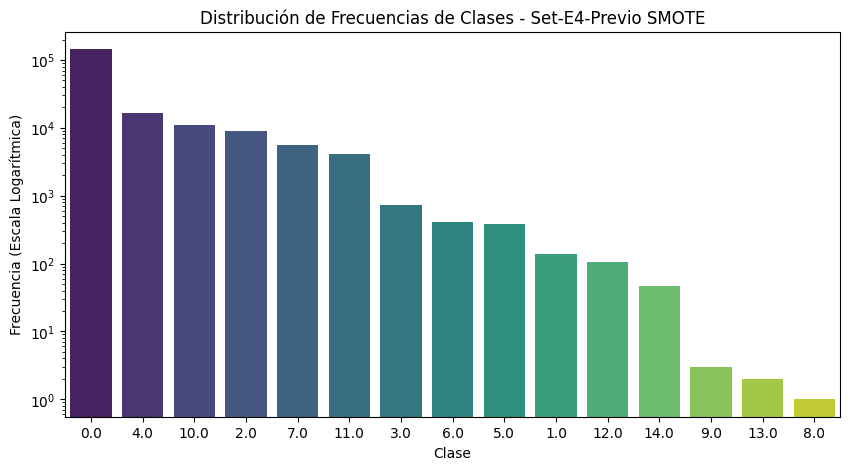

Analisis de Distribucion: SET-E5-PREVIO SMOTE
Total de muestras: 30,033
Número de clases: 15
Imbalance Ratio: 23575.00:1

 Clase  Conteo Porcentaje (%)
   0.0   23575       78.4970%
   4.0    2661        8.8603%
  10.0    1830        6.0933%
   2.0    1474        4.9079%
   3.0     119        0.3962%
   7.0      92        0.3063%
  11.0      68        0.2264%
   6.0      67        0.2231%
   5.0      64        0.2131%
   9.0      25        0.0832%
   1.0      23        0.0766%
  12.0      18        0.0599%
  14.0       8        0.0266%
   8.0       8        0.0266%
  13.0       1        0.0033%


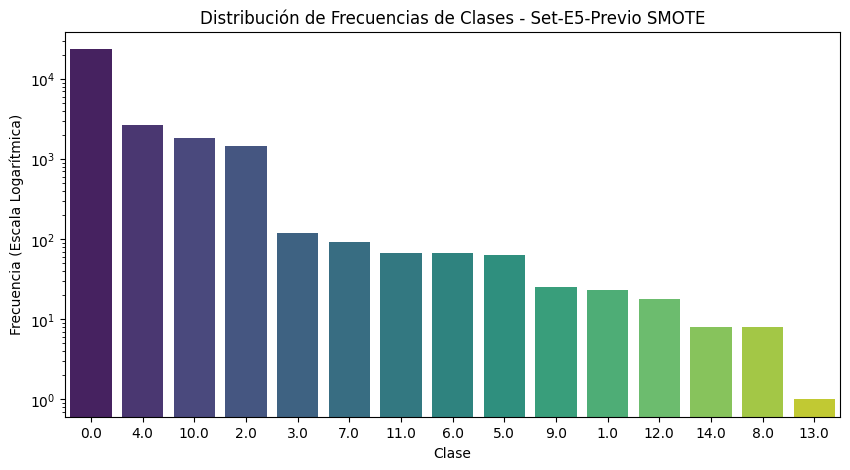

In [12]:
import joblib
import numpy as np

carpeta_sets = "Sets_Expertos_MoE_2"

X_train_E1 = joblib.load(f"{carpeta_sets}/X_train_E1_Benigno_Y_Ataques_Camuflados.joblib").astype(np.float32)
y_train_E1 = joblib.load(f"{carpeta_sets}/y_train_E1_Benigno_Y_Ataques_Camuflados.joblib").astype(np.float32)

X_train_E2 = joblib.load(f"{carpeta_sets}/X_train_E2_Mayoritarios.joblib").astype(np.float32)
y_train_E2 = joblib.load(f"{carpeta_sets}/y_train_E2_Mayoritarios.joblib").astype(np.float32)

X_train_E3 = joblib.load(f"{carpeta_sets}/X_train_E3_DoS.joblib").astype(np.float32)
y_train_E3 = joblib.load(f"{carpeta_sets}/y_train_E3_DoS.joblib").astype(np.float32)

X_train_E4 = joblib.load(f"{carpeta_sets}/X_train_E4_Patator.joblib").astype(np.float32)
y_train_E4 = joblib.load(f"{carpeta_sets}/y_train_E4_Patator.joblib").astype(np.float32)

X_train_E5 = joblib.load(f"{carpeta_sets}/X_train_E5_Minoritarios.joblib").astype(np.float32)
y_train_E5 = joblib.load(f"{carpeta_sets}/y_train_E5_Minoritarios.joblib").astype(np.float32)

classes, counts = analizar_distribuciones(y_train_E1, "Set-E1-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E2, "Set-E2-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E3, "Set-E3-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E4, "Set-E4-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E5, "Set-E5-Previo SMOTE")

Analisis de Distribucion: SET-E1-PREVIO SMOTE
Total de muestras: 1,465,903
Número de clases: 15
Imbalance Ratio: 1433001.00:1

 Clase  Conteo Porcentaje (%)
   0.0 1433001       97.7555%
   4.0   12526        0.8545%
  10.0    8612        0.5875%
   2.0    6937        0.4732%
   1.0    1376        0.0939%
  12.0    1055        0.0720%
   3.0     558        0.0381%
  14.0     456        0.0311%
   7.0     431        0.0294%
  11.0     320        0.0218%
   6.0     315        0.0215%
   5.0     298        0.0203%
  13.0      15        0.0010%
   9.0       2        0.0001%
   8.0       1        0.0001%


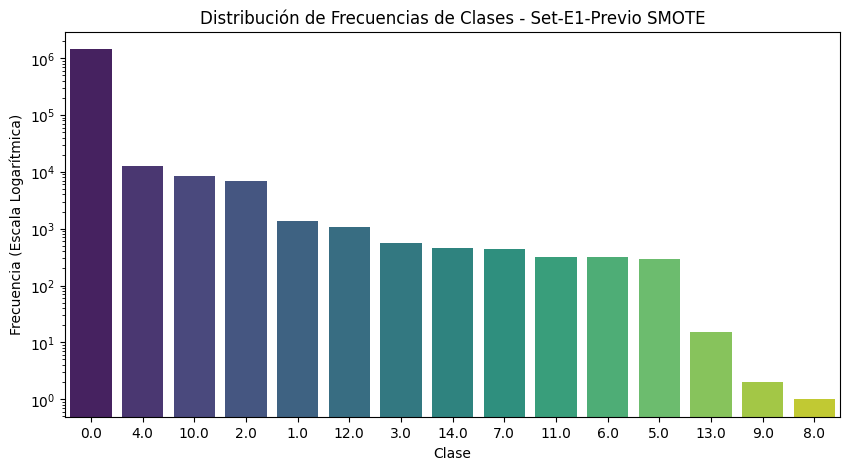

Analisis de Distribucion: SET-E2-PREVIO SMOTE
Total de muestras: 962,621
Número de clases: 15
Imbalance Ratio: 147150.75:1

 Clase  Conteo Porcentaje (%)
   0.0  588603       61.1459%
   4.0  161751       16.8032%
  10.0  111251       11.5571%
   2.0   89619        9.3099%
   3.0    2960        0.3075%
   7.0    2283        0.2372%
  11.0    1696        0.1762%
   6.0    1667        0.1732%
   5.0    1581        0.1642%
   1.0     566        0.0588%
  12.0     434        0.0451%
  14.0     188        0.0195%
   9.0      11        0.0011%
  13.0       7        0.0007%
   8.0       4        0.0004%


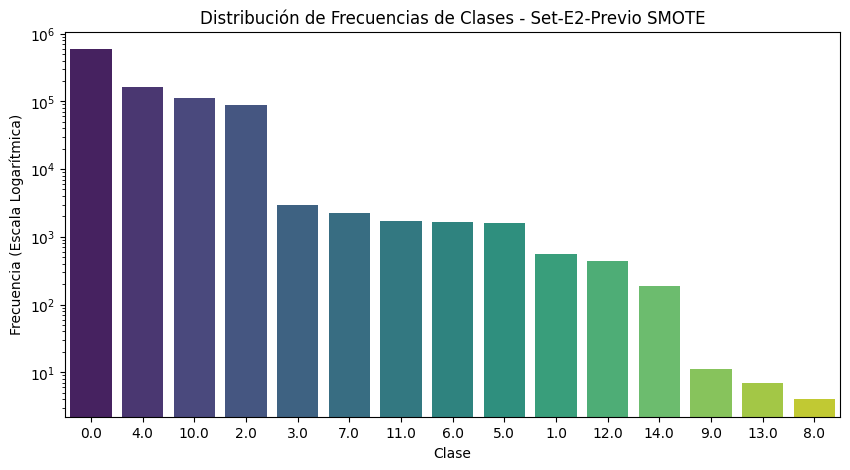

Analisis de Distribucion: SET-E3-PREVIO SMOTE
Total de muestras: 92,091
Número de clases: 15
Imbalance Ratio: 61003.00:1

 Clase  Conteo Porcentaje (%)
   0.0   61003       66.2421%
   3.0    7205        7.8238%
   4.0    6885        7.4763%
  10.0    4736        5.1427%
   6.0    4057        4.4054%
   5.0    3849        4.1796%
   2.0    3815        4.1426%
   7.0     237        0.2574%
  11.0     176        0.1911%
   1.0      59        0.0641%
  12.0      45        0.0489%
  14.0      20        0.0217%
   9.0       2        0.0022%
   8.0       1        0.0011%
  13.0       1        0.0011%


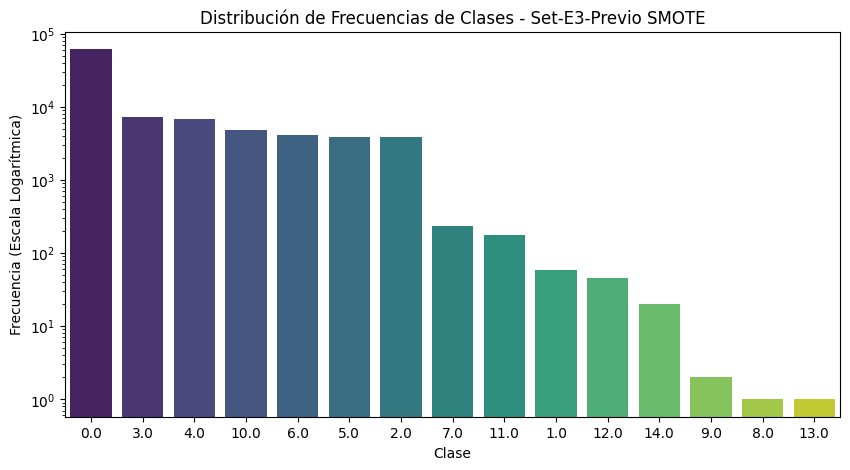

Analisis de Distribucion: SET-E4-PREVIO SMOTE
Total de muestras: 192,245
Número de clases: 15
Imbalance Ratio: 144239.00:1

 Clase  Conteo Porcentaje (%)
   0.0  144239       75.0287%
   4.0   16281        8.4689%
  10.0   11198        5.8249%
   2.0    9021        4.6924%
   7.0    5557        2.8906%
  11.0    4128        2.1473%
   3.0     726        0.3776%
   6.0     409        0.2127%
   5.0     388        0.2018%
   1.0     139        0.0723%
  12.0     107        0.0557%
  14.0      46        0.0239%
   9.0       3        0.0016%
  13.0       2        0.0010%
   8.0       1        0.0005%


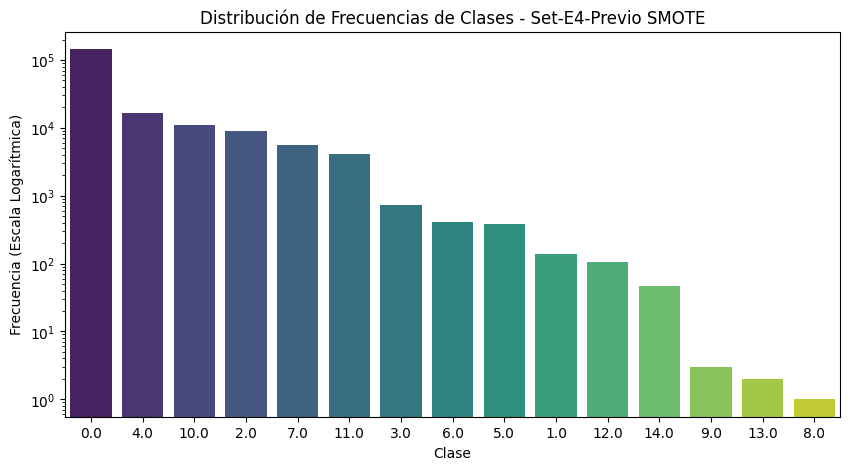

Analisis de Distribucion: SET-E5-PREVIO SMOTE
Total de muestras: 30,033
Número de clases: 15
Imbalance Ratio: 23575.00:1

 Clase  Conteo Porcentaje (%)
   0.0   23575       78.4970%
   4.0    2661        8.8603%
  10.0    1830        6.0933%
   2.0    1474        4.9079%
   3.0     119        0.3962%
   7.0      92        0.3063%
  11.0      68        0.2264%
   6.0      67        0.2231%
   5.0      64        0.2131%
   9.0      25        0.0832%
   1.0      23        0.0766%
  12.0      18        0.0599%
  14.0       8        0.0266%
   8.0       8        0.0266%
  13.0       1        0.0033%


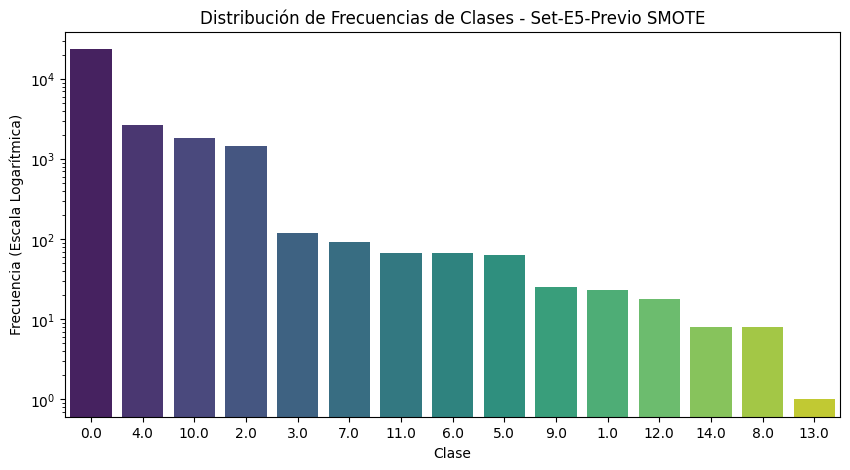

In [13]:
import joblib
import numpy as np

carpeta_sets = "Sets_Expertos_MoE_2"

X_train_E1 = joblib.load(f"{carpeta_sets}/X_train_E1_Benigno_Y_Ataques_Camuflados.joblib").astype(np.float32)
y_train_E1 = joblib.load(f"{carpeta_sets}/y_train_E1_Benigno_Y_Ataques_Camuflados.joblib").astype(np.float32)

X_train_E2 = joblib.load(f"{carpeta_sets}/X_train_E2_Mayoritarios.joblib").astype(np.float32)
y_train_E2 = joblib.load(f"{carpeta_sets}/y_train_E2_Mayoritarios.joblib").astype(np.float32)

X_train_E3 = joblib.load(f"{carpeta_sets}/X_train_E3_DoS.joblib").astype(np.float32)
y_train_E3 = joblib.load(f"{carpeta_sets}/y_train_E3_DoS.joblib").astype(np.float32)

X_train_E4 = joblib.load(f"{carpeta_sets}/X_train_E4_Patator.joblib").astype(np.float32)
y_train_E4 = joblib.load(f"{carpeta_sets}/y_train_E4_Patator.joblib").astype(np.float32)

X_train_E5 = joblib.load(f"{carpeta_sets}/X_train_E5_Minoritarios.joblib").astype(np.float32)
y_train_E5 = joblib.load(f"{carpeta_sets}/y_train_E5_Minoritarios.joblib").astype(np.float32)

for i, y in enumerate([y_train_E1, y_train_E2, y_train_E3, y_train_E4, y_train_E5]):
    analizar_distribuciones(y, f"Set-E{i+1}-Previo SMOTE")

In [14]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import os
from functools import partial

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TensorDataLoader:
    
    def __init__(self, X, y, batch_size, shuffle=False):
        self.X = torch.tensor(X.values if hasattr(X, 'values') else X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.long).to(device)
        self.dataset_len = self.X.shape[0]
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):
        if self.shuffle:
            self.indices = torch.randperm(self.dataset_len, device=device)
        else:
            self.indices = None
        self.i = 0
        return self

    def __next__(self):
        if self.i >= self.dataset_len:
            raise StopIteration
        
        if self.indices is not None:
            idx = self.indices[self.i : self.i + self.batch_size]
            batch_X = self.X[idx]
            batch_y = self.y[idx]
        else:
            batch_X = self.X[self.i : self.i + self.batch_size]
            batch_y = self.y[self.i : self.i + self.batch_size]
            
        self.i += self.batch_size
        return batch_X, batch_y

    def __len__(self):
        return (self.dataset_len + self.batch_size - 1)

class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout_rate, activation_name, num_classes=15):
        super().__init__()
        activations = {
            'leaky_relu': nn.LeakyReLU(0.01),
            'gelu': nn.GELU(),
            'relu': nn.ReLU()
        }
        activation_layer = activations[activation_name]
        
        layers = []
        in_f = input_dim
        for out_f in hidden_layers:
            layers.append(nn.Linear(in_f, out_f))
            layers.append(nn.BatchNorm1d(out_f))
            layers.append(activation_layer)
            layers.append(nn.Dropout(dropout_rate))
            in_f = out_f
            
        layers.append(nn.Linear(in_f, num_classes))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x): 
        return self.net(x)
    
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        pt = torch.exp(-ce_loss)
        
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [20]:
def objective_experto(trial, X_train, y_train, X_val, y_val, input_dim, nombre_experto, clases_objetivo):
    batch_size = trial.suggest_categorical('batch_size', [4096, 8192, 16384])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    activation_name = trial.suggest_categorical('activation', ['leaky_relu', 'gelu'])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    focal_gamma = trial.suggest_float('focal_gamma', 0.0, 5.0)
    epochs = trial.suggest_int('epochs', 50, 100)
    
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_layers = []
    base_units = trial.suggest_int('n_units_l0', 256, 1024, step=256)
    hidden_layers.append(base_units)
    
    prev_units = base_units
    for i in range(1, n_layers):
        units = trial.suggest_int(f'n_units_l{i}', 64, prev_units, step=64)
        hidden_layers.append(units)
        prev_units = units

    train_loader = TensorDataLoader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = TensorDataLoader(X_val, y_val, batch_size=batch_size*2, shuffle=False)

    model = TabularMLP(input_dim=input_dim, hidden_layers=hidden_layers, 
                       dropout_rate=dropout_rate, activation_name=activation_name).to(device)
    
    criterion = FocalLoss(gamma=focal_gamma)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    scaler = torch.amp.GradScaler('cuda')

    best_macro_f1 = 0.0
    patience_counter = 0
    early_stopping_patience = 10
    best_model_state = None 
    
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
        model.eval()
        y_true_list, y_pred_list = [], []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                with torch.amp.autocast('cuda'):
                    outputs = model(batch_X)
                _, preds = torch.max(outputs, 1)
                y_true_list.append(batch_y)
                y_pred_list.append(preds)
                
        y_true_all = torch.cat(y_true_list).cpu().numpy()
        y_pred_all = torch.cat(y_pred_list).cpu().numpy()
                
        current_macro_f1 = f1_score(y_true_all, y_pred_all, labels=clases_objetivo, average='macro', zero_division=0)
        scheduler.step(current_macro_f1)
    
        trial.report(current_macro_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
        if current_macro_f1 > best_macro_f1:
            best_macro_f1 = current_macro_f1
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= early_stopping_patience:
            break

    if best_model_state is not None:
        os.makedirs("Models_Experts_Second_Architecture", exist_ok=True)
        ruta_guardado = f"Models_Experts_Second_Architecture/{nombre_experto}_trial_{trial.number}.pth"
        torch.save(best_model_state, ruta_guardado)
        trial.set_user_attr("ruta_pesos", ruta_guardado)
        trial.set_user_attr("hidden_layers", hidden_layers)

    return best_macro_f1

In [16]:
clases_por_experto = {
    1: [0, 1, 12, 13, 14],
    2: [2, 4, 10],
    3: [3, 5, 6],
    4: [7, 11],
    5: [8, 9]
}

tipos_oversampling = ['none', 'smote', 'smote_tomek', 'smote_enn']

In [17]:
import optuna
import copy
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from functools import partial

class DynamicGatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts, hidden_layers, dropout_rate, activation_name):
        super(DynamicGatingNetwork, self).__init__()
        activations = {
            'leaky_relu': nn.LeakyReLU(0.01),
            'gelu': nn.GELU()
        }
        activation_layer = activations.get(activation_name, nn.LeakyReLU(0.01))
        
        layers = []
        in_f = input_dim
        for out_f in hidden_layers:
            layers.append(nn.Linear(in_f, out_f))
            layers.append(nn.BatchNorm1d(out_f))
            layers.append(activation_layer)
            layers.append(nn.Dropout(dropout_rate))
            in_f = out_f
            
        layers.append(nn.Linear(in_f, num_experts))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=1)

In [18]:
def save_confusion_matrix(y_true, y_pred, name, phase="Val"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f'Mixture of Experts - ({phase})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'Logs_MoE_Second_Architecture/{name}.png')
    plt.close()

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score
import optuna
import copy
import os

class OptunaTabularMoESoftRouting(nn.Module):
    def __init__(self, lista_expertos, gating_network):
        super(OptunaTabularMoESoftRouting, self).__init__()
        self.experts = nn.ModuleList(lista_expertos)
        self.num_experts = len(self.experts)
        self.gating = gating_network
        
        for expert in self.experts:
            for param in expert.parameters():
                param.requires_grad = True

    def forward(self, x):
        gating_logits = self.gating(x) 
        
        pesos_gating = torch.softmax(gating_logits, dim=1)

        salidas_expertos = [expert(x) for expert in self.experts] 
        salidas_apiladas = torch.stack(salidas_expertos, dim=1)
        
        pesos_gating = pesos_gating.unsqueeze(2)
        salidas_ponderadas = salidas_apiladas * pesos_gating
        
        salida_final = torch.sum(salidas_ponderadas, dim=1)
        return salida_final

In [28]:
import os
import copy
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import optuna
from functools import partial
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

def objective_moe_gating(trial, X_train, y_train, X_val, y_val, input_dim, lista_expertos, oversampling):
    batch_size = trial.suggest_categorical('batch_size', [8192, 16384])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
    activation_name = trial.suggest_categorical('activation', ['leaky_relu', 'gelu'])
    
    lr_gating = trial.suggest_float('lr_gating', 1e-4, 1e-2, log=True) 
    lr_experts = trial.suggest_float('lr_experts', 1e-6, 1e-4, log=True) 
    
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    focal_gamma = trial.suggest_float('focal_gamma', 0.0, 5.0) 
    epochs = trial.suggest_int('epochs', 50, 100)
    
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layers = []
    base_units = trial.suggest_int('n_units_l0', 64, 512, step=64)
    hidden_layers.append(base_units)
    
    prev_units = base_units
    for i in range(1, n_layers):
        units = trial.suggest_int(f'n_units_l{i}', 64, prev_units, step=64)
        hidden_layers.append(units)
        prev_units = units

    train_loader = TensorDataLoader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = TensorDataLoader(X_val, y_val, batch_size=batch_size*2, shuffle=False)

    gating_net = DynamicGatingNetwork(input_dim, len(lista_expertos), hidden_layers, dropout_rate, activation_name)
    moe_model = OptunaTabularMoESoftRouting(lista_expertos, gating_net).to(device)

    criterion = FocalLoss(gamma=focal_gamma) 
    optimizer = optim.AdamW([
        {'params': moe_model.gating.parameters(), 'lr': lr_gating},
        {'params': moe_model.experts.parameters(), 'lr': lr_experts}
    ], weight_decay=weight_decay)

    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.amp.GradScaler('cuda')

    best_macro_f1 = 0.0
    patience_counter = 0
    early_stop_patience = 6
    best_model_state = None 

    for epoch in range(epochs):
        moe_model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = moe_model(batch_X)
                loss = criterion(outputs, batch_y)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
        moe_model.eval()
        y_true_list, y_pred_list = [], []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                with torch.amp.autocast('cuda'):
                    outputs = moe_model(batch_X)
                _, preds = torch.max(outputs, 1)
                y_true_list.append(batch_y)
                y_pred_list.append(preds)
                
        y_true_all = torch.cat(y_true_list).cpu().numpy()
        y_pred_all = torch.cat(y_pred_list).cpu().numpy()
                
        current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        scheduler.step(current_f1)

        trial.report(current_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
        if current_f1 > best_macro_f1:
            best_macro_f1 = current_f1
            patience_counter = 0
            best_model_state = copy.deepcopy(moe_model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= early_stop_patience:
            break

    if best_model_state is not None:
        os.makedirs("Models_Gating_Second_Architecture", exist_ok=True)
        ruta_guardado = f"Models_Gating_Second_Architecture/Gating_Soft_trial_{trial.number}_{oversampling}.pth"
        torch.save(best_model_state, ruta_guardado)
        trial.set_user_attr("ruta_pesos", ruta_guardado)
        trial.set_user_attr("hidden_layers", hidden_layers)

    return best_macro_f1

In [21]:
def automatizar_evaluacion_moe(moe_model, val_loader, test_loader, class_names, method_name):
    log_dir = "Logs_MoE_Second_Architecture"
    os.makedirs(log_dir, exist_ok=True)
    
    moe_model.eval()
    
    y_true_val, y_pred_val = [], []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            with torch.amp.autocast('cuda'):
                outputs = moe_model(batch_X)
            _, preds = torch.max(outputs, 1)
            y_true_val.extend(batch_y.cpu().numpy())
            y_pred_val.extend(preds.cpu().numpy())

    reporte_val = classification_report(y_true_val, y_pred_val, target_names=[str(c) for c in class_names], digits=4)
    with open(f"{log_dir}/Reporte_Val_{method_name}.txt", "w") as f:
        f.write(reporte_val)
    save_confusion_matrix(y_true_val, y_pred_val, f"MoE_CM_{method_name}_Val", phase="Val")

    y_true_test, y_pred_test = [], []
    all_gating_weights = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            with torch.amp.autocast('cuda'):
                outputs = moe_model(batch_X)
                gating_logits = moe_model.gating.net(batch_X)
                gating_probs = torch.softmax(gating_logits, dim=1)
                
            _, preds = torch.max(outputs, 1)
            y_true_test.extend(batch_y.cpu().numpy())
            y_pred_test.extend(preds.cpu().numpy())
            all_gating_weights.append(gating_probs.cpu().numpy())

    reporte_test = classification_report(y_true_test, y_pred_test, target_names=[str(c) for c in class_names], digits=4)
    with open(f"{log_dir}/Reporte_Test_{method_name}.txt", "w") as f:
        f.write(reporte_test)
    save_confusion_matrix(y_true_test, y_pred_test, f"MoE_CM_{method_name}_Test", phase="Test")

    all_gating_weights = np.vstack(all_gating_weights)
    y_true_test_np = np.array(y_true_test)
    
    num_classes = len(class_names)
    num_experts = all_gating_weights.shape[1]
    expert_usage_matrix = np.zeros((num_classes, num_experts))

    for i in range(num_classes):
        class_indices = (y_true_test_np == i)
        if np.any(class_indices):
            expert_usage_matrix[i] = np.mean(all_gating_weights[class_indices], axis=0)

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        expert_usage_matrix, 
        annot=True, 
        cmap="Blues", 
        fmt=".3f",
        xticklabels=[f"Experto {i+1}" for i in range(num_experts)],
        yticklabels=[str(c) for c in class_names]
    )
    plt.title(f"Matriz de Utilizacion de Expertos (Test - {method_name})")
    plt.xlabel("Asignacion Promedio")
    plt.ylabel("Clases Reales")
    plt.tight_layout()
    plt.savefig(f"{log_dir}/Matriz_Utilizacion_{method_name}_Test.png", dpi=300, bbox_inches='tight')
    plt.close()

In [22]:
def automatizar_fase1_expertos(metodo_oversampling, X_val, y_val_1d, clases_por_experto, n_trials=100):
    lista_expertos_entrenados = []
    os.makedirs("Models_Experts_Second_Architecture", exist_ok=True)
    os.makedirs("Models_Final_Second_Architecture", exist_ok=True)

    for i in range(1, 6):
        ruta_X = f"Sets_Oversampling_MoE_2/X_train_{metodo_oversampling}_Experto_{i}.joblib"
        ruta_y = f"Sets_Oversampling_MoE_2/y_train_{metodo_oversampling}_Experto_{i}.joblib"
        nombre_exp = f"Experto_{i}_{metodo_oversampling}"

        X_train_exp = joblib.load(ruta_X).astype(np.float32)
        y_train_exp = joblib.load(ruta_y)
        if isinstance(y_train_exp, pd.DataFrame) or isinstance(y_train_exp, pd.Series):
            y_train_exp = y_train_exp.values.ravel()
        y_train_exp = y_train_exp.astype(np.float32)

        input_dim_exp = X_train_exp.shape[1]

        obj_func = partial(
            objective_experto, 
            X_train=X_train_exp, 
            y_train=y_train_exp, 
            X_val=X_val, 
            y_val=y_val_1d, 
            input_dim=input_dim_exp,
            nombre_experto=nombre_exp,
            clases_objetivo=clases_por_experto[i] 
        )

        study_expert = optuna.create_study(direction="maximize", study_name=nombre_exp)
        study_expert.optimize(obj_func, n_trials=n_trials)

        best_params = study_expert.best_params
        best_hidden_layers = study_expert.best_trial.user_attrs['hidden_layers']

        experto_model = TabularMLP(
            input_dim=input_dim_exp, 
            hidden_layers=best_hidden_layers, 
            dropout_rate=best_params['dropout_rate'], 
            activation_name=best_params['activation']
        ).to(device)

        ruta_pesos = study_expert.best_trial.user_attrs['ruta_pesos']
        experto_model.load_state_dict(torch.load(ruta_pesos, map_location=device))
        
        with open(f"Models_Final_Second_Architecture/Arquitectura_{nombre_exp}.json", "w") as f:
            json.dump({"hidden_layers": best_hidden_layers, "dropout": best_params['dropout_rate'], "activation": best_params['activation']}, f, indent=4)

        lista_expertos_entrenados.append(experto_model)

        del X_train_exp, y_train_exp
        gc.collect()

    return lista_expertos_entrenados

In [25]:
def automatizar_fase2_gating(metodo_oversampling, lista_expertos, X_train, y_train, X_val, y_val, input_dim, n_trials_optuna=100):
    obj_func = partial(
        objective_moe_gating, 
        X_train=X_train, 
        y_train=y_train, 
        X_val=X_val, 
        y_val=y_val, 
        input_dim=input_dim,
        lista_expertos=lista_expertos,
        oversampling=metodo_oversampling
    )

    study_name = f"Gating_Optimization_{metodo_oversampling}"
    study = optuna.create_study(direction="maximize", study_name=study_name)
    study.optimize(obj_func, n_trials=n_trials_optuna)

    best_params = study.best_params
    best_hidden_layers = study.best_trial.user_attrs['hidden_layers']

    config_arq = {
        "input_dim": int(input_dim),
        "num_experts": len(lista_expertos),
        "hidden_layers": best_hidden_layers,
        "dropout_rate": float(best_params['dropout_rate']),
        "activation_name": best_params['activation'],
        "lr_gating": float(best_params['lr_gating']),
        "lr_experts": float(best_params['lr_experts'])
    }
    with open(f"Models_Final_Second_Architecture/MoE_{metodo_oversampling}_Arquitectura.json", "w") as f:
        json.dump(config_arq, f, indent=4)

    mejor_gating = DynamicGatingNetwork(
        input_dim=input_dim, 
        num_experts=len(lista_expertos), 
        hidden_layers=best_hidden_layers, 
        dropout_rate=best_params['dropout_rate'], 
        activation_name=best_params['activation']
    )
    mejor_moe_model = OptunaTabularMoESoftRouting(lista_expertos, mejor_gating).to(device)

    ruta_checkpoint = study.best_trial.user_attrs['ruta_pesos']
    mejor_moe_model.load_state_dict(torch.load(ruta_checkpoint, map_location=device))

    return mejor_moe_model

In [24]:
def pipeline_maestro_moe(
    metodo_oversampling, 
    X_train_base, y_train_base, 
    X_val, y_val_1d, 
    X_test, y_test_1d, 
    clases_por_experto, 
    class_names, 
    n_trials_expertos=100,
    n_trials_gating=100
):
    input_dim_total = X_train_base.shape[1]

    lista_expertos = automatizar_fase1_expertos(
        metodo_oversampling=metodo_oversampling, 
        X_val=X_val, 
        y_val_1d=y_val_1d, 
        clases_por_experto=clases_por_experto, 
        n_trials=n_trials_expertos
    )

    moe_final = automatizar_fase2_gating(
        metodo_oversampling=metodo_oversampling, 
        lista_expertos=lista_expertos, 
        X_train=X_train_base, 
        y_train=y_train_base, 
        X_val=X_val, 
        y_val=y_val_1d, 
        input_dim=input_dim_total, 
        n_trials_optuna=n_trials_gating
    )

    batch_size_eval = 16384
    val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
    test_loader_moe = TensorDataLoader(X_test, y_test_1d, batch_size=batch_size_eval, shuffle=False)

    automatizar_evaluacion_moe(
        moe_model=moe_final, 
        val_loader=val_loader_moe, 
        test_loader=test_loader_moe, 
        class_names=class_names, 
        method_name=metodo_oversampling.upper()
    )

In [ ]:
X_train_base = joblib.load("Sets_Oversampling_MoE_2/X_train_none_Experto_1.joblib").astype(np.float32)
y_train_base = joblib.load("Sets_Oversampling_MoE_2/y_train_none_Experto_1.joblib")
if isinstance(y_train_base, pd.DataFrame) or isinstance(y_train_base, pd.Series):
    y_train_base = y_train_base.values.ravel()
y_train_base = y_train_base.astype(np.float32)

clases_por_experto_arq2 = {
    1: [0, 1, 12, 13, 14],
    2: [2, 4, 10],
    3: [3, 5, 6],
    4: [7, 11],
    5: [8, 9]
}

tipos_oversampling = ['smote', 'smote_tomek', 'smote_enn']

for metodo in tipos_oversampling:
    pipeline_maestro_moe(
        metodo_oversampling=metodo, 
        X_train_base=X_train_base, y_train_base=y_train_base, 
        X_val=X_val, y_val_1d=y_val_1d, 
        X_test=X_test, y_test_1d=y_test_1d, 
        clases_por_experto=clases_por_experto_arq2, 
        class_names=class_names, 
        n_trials_expertos=100,
        n_trials_gating=100
    )